In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [4]:
df=pd.read_csv(r"C:\Users\HP\Downloads\DataCoSupplyChainDataset.csv\stg_supply_chain1.csv")

In [4]:
print(f"data shape: {df.shape}")
df.info()

data shape: (180519, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  object 
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  object 
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  object 
 9   order_city                   180519 non-null  object 
 10  order_country                180519 non-null  object 
 11  order_customer_id            180519 non-null  int64  
 12  order_date                   1805

Exploratory Data Analysis (EDA) & Correlation Analysis

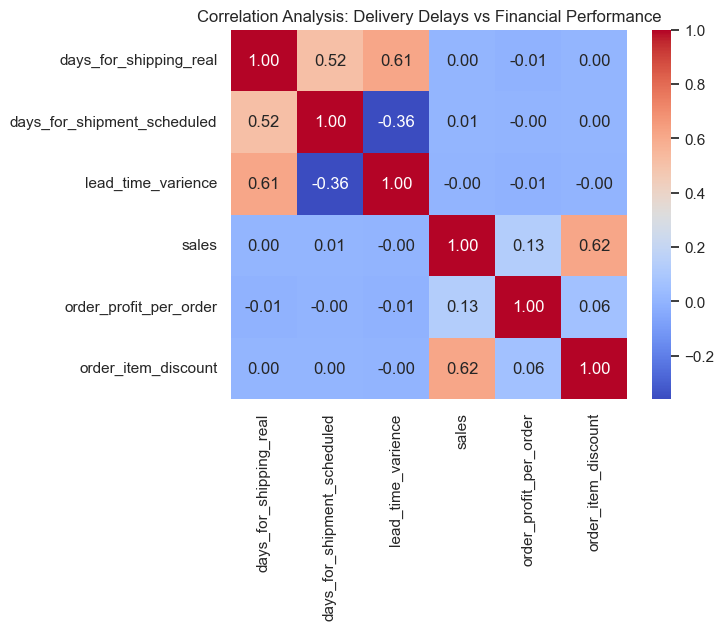

In [14]:
df['lead_time_varience']= df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
df['late_delivery_risk'] = np.where(df['lead_time_varience']>0, 1,0)

correlation_col = ['days_for_shipping_real','days_for_shipment_scheduled','lead_time_varience', 'sales','order_profit_per_order','order_item_discount']

plt.Figure(figsize=(8,6))
sns.heatmap(df[correlation_col].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis: Delivery Delays vs Financial Performance')
plt.show()

In [15]:
profit_by_delay=df.groupby('delivery_status')['order_profit_per_order'].mean().reset_index()
print('Average profit by delivery status:')
print(profit_by_delay)


Average profit by delivery status:
     delivery_status  order_profit_per_order
0   Advance shipping               22.485701
1      Late delivery               21.621707
2  Shipping canceled               20.696717
3   Shipping on time               22.709146


ABC Analysis (Revenue-Based Segmentation)

In [7]:
abc_df= df.groupby(['product_card_id','product_name']).agg(
    total_revenue=('sales','sum'),
    total_unit_sold=('order_item_quantity','sum'),
    
).reset_index()

abc_df=abc_df.sort_values(by='total_revenue',ascending=False).reset_index(drop=True)

abc_df['cumulative_revenue']=abc_df['total_revenue'].cumsum()
total_catalog_revenue=abc_df['total_revenue'].sum()
abc_df['cumulative_revenue_pct']=(abc_df['cumulative_revenue']/total_catalog_revenue)*100

def assign_abc(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'
    
abc_df['abc_class']=abc_df['cumulative_revenue_pct'].apply(assign_abc)

print('ABC Analysis Revenue-Based Segmentation ')
print(abc_df['abc_class'].value_counts())

ABC Analysis Revenue-Based Segmentation 
abc_class
C    95
B    16
A     7
Name: count, dtype: int64


In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate monthly sales per product
monthly_demand = df.groupby(['product_card_id', 'order_month'])['order_item_quantity'].sum().unstack(fill_value=0)

# Calculate Mean, Standard Deviation and CV
xyz_df = pd.DataFrame(index=monthly_demand.index)
xyz_df['mean_demand'] = monthly_demand.mean(axis=1)
xyz_df['std_demand'] = monthly_demand.std(axis=1)

# Handle division by zero
xyz_df['cv'] = np.where(xyz_df['mean_demand'] > 0, xyz_df['std_demand'] / xyz_df['mean_demand'], 0)

# Assign XYZ Categories
def assign_xyz(cv):
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_df['xyz_class'] = xyz_df['cv'].apply(assign_xyz)

In [9]:
inventory_matrix = pd.merge(abc_df, xyz_df[['xyz_class', 'cv']], on='product_card_id', how='left')
inventory_matrix['abc_xyz_group']=inventory_matrix['xyz_class'] + inventory_matrix['abc_class']

def set_inventory_policies(group):
    policies ={
        'AX': 'Tight Control: Automated Reordering, Minimal Safety Stock',
        'AY': 'Moderate Safety Stock, Regular Review',
        'AZ': 'High Safety Stock Buffer (High Value, High Volatility)',
        'BX': 'Standard Control, Periodic Review',
        'BY': 'Moderate Buffer Stock',
        'BZ': 'Dynamic Reorder Points',
        'CX': 'Bulk Reordering, Low Priority',
        'CY': 'Low Buffer Stock',
        'CZ': 'On-Demand / Minimal Stocking (Stockout Risk OK)'
    }
    return policies.get(group, 'standard policy')

inventory_matrix['inventory_policy']=inventory_matrix['abc_xyz_group'].apply(set_inventory_policies)

inventory_matrix.to_csv('abc_xyz_inventory_segmented.csv', index=False)
print("Segmented inventory dataset saved successfully!")
    

Segmented inventory dataset saved successfully!
